# Notebook – Faysal
## Project: Voorspelling Jeugdpopulatie Almere (CBS Wijken & Buurten)

**Doel van dit notebook (fase 1):**  
De gemeente Almere wil beter kunnen inspelen op de zorgbehoeften van kinderen en jongeren in verschillende wijken. Wijken met een relatief groot aantal jongeren kunnen bijvoorbeeld meer ondersteuning nodig hebben van wijkteams of jeugdzorgvoorzieningen.

Om deze reden wil de gemeente inzicht krijgen in hoe de jeugdpopulatie zich ontwikkelt per wijk. Door deze ontwikkeling beter te begrijpen en te voorspellen, kan de gemeente beleid en ondersteuning tijdig aanpassen. 

Windesheim Data Science opdrach…

De analyse wordt uitgevoerd op basis van open data van het CBS (Kerncijfers wijken en buurten). Deze dataset bevat demografische gegevens per wijk, zoals het totaal aantal inwoners en het aantal inwoners per leeftijdsgroep.

**Business probleem**

De gemeente beschikt over historische data over de bevolkingssamenstelling per wijk, maar heeft nog geen eenvoudig model dat kan helpen bij het inschatten van toekomstige ontwikkelingen in de jeugdpopulatie.

Zonder dit inzicht is het moeilijker om:

- capaciteit van wijkteams te plannen
- jeugdzorgvoorzieningen goed te verdelen
- tijdig te reageren op groei van het aantal jongeren in bepaalde wijken

**Business vraag**

Hoe ontwikkelt het aantal jongeren in de leeftijdsgroepen 0–15 jaar en 15–25 jaar zich per wijk in Almere, en kan deze ontwikkeling worden gebruikt om toekomstige aantallen te voorspellen?

**Data mining doel**

Het doel van dit notebook is om een eenvoudig voorspellend model te bouwen dat de relatie onderzoekt tussen verschillende leeftijdsgroepen binnen een wijk.

Specifiek wordt onderzocht of het aantal jongeren van 15–25 jaar samenhangt met het aantal kinderen van 0–15 jaar in dezelfde wijk.

Dit gebeurt met een enkelvoudig lineair regressiemodel.

**Modelopzet**

Voor dit individuele model wordt gebruik gemaakt van:

Predictor
Aantal jongeren 15–25 jaar

Target
Aantal jongeren 0–15 jaar

De analyse wordt uitgevoerd per wijk, zodat verschillen tussen wijken zichtbaar blijven.

**Onderzoeksvraag van dit model**

Bestaat er een structurele relatie tussen het aantal jongeren van 15–25 jaar en het aantal kinderen van 0–15 jaar binnen wijken in Almere?

Met andere woorden:

Hebben wijken met relatief veel jongeren ook relatief veel kinderen?

**Dataset**

Voor dit model wordt gebruik gemaakt van de dataset:

../../data/processed/df_v10_ratio_temp.csv

Deze dataset bevat demografische gegevens per wijk en jaar, waaronder:
- Wijk
- Jaar
- Totaal aantal inwoners
- Aantal jongeren 0–15 jaar
- Aantal jongeren 15–25 jaar

Deze gegevens vormen de basis voor het regressiemodel dat in latere fases wordt gebouwd.

In [204]:
import pandas as pd
from pathlib import Path
 
path = Path("../../data/processed/df_v6_clean_final.csv")
 
df = pd.read_csv(path)
df.head()

,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar
0,2018-01-01,WK003401,22790,3975,2420,2018
1,2019-01-01,WK003401,22875,3945,2415,2019
2,2020-01-01,WK003401,23275,4005,2485,2020
3,2021-01-01,WK003401,23530,4180,2465,2021
4,2022-01-01,WK003401,1635,175,150,2022


In [205]:
df.shape, df.columns

((237, 6),
 Index(['Peildatum', 'Wijk', 'AantalInwoners_5', 'k_0Tot15Jaar_8',
        'k_15Tot25Jaar_9', 'Jaar'],
       dtype='str'))

In [206]:
df.info()
df.describe(include="all")
df.isnull().sum()
df.duplicated().sum()

<class 'pandas.DataFrame'>
RangeIndex: 237 entries, 0 to 236
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Peildatum         237 non-null    str  
 1   Wijk              237 non-null    str  
 2   AantalInwoners_5  237 non-null    int64
 3   k_0Tot15Jaar_8    237 non-null    int64
 4   k_15Tot25Jaar_9   237 non-null    int64
 5   Jaar              237 non-null    int64
dtypes: int64(4), str(2)
memory usage: 11.2 KB


np.int64(0)

In [207]:
df["Peildatum"] = pd.to_datetime(df["Peildatum"], errors="coerce")
df["Jaar"] = df["Peildatum"].dt.year
 
df[["Peildatum", "Jaar"]].head()

,Peildatum,Jaar
0,2018-01-01,2018
1,2019-01-01,2019
2,2020-01-01,2020
3,2021-01-01,2021
4,2022-01-01,2022


In [208]:
kol_totaal = "AantalInwoners_5"
kol_0_15 = "k_0Tot15Jaar_8"
kol_15_25 = "k_15Tot25Jaar_9"
 
checks = {
    "negatief_0_15": (df[kol_0_15] < 0).sum(),
    "negatief_15_25": (df[kol_15_25] < 0).sum(),
    "negatief_totaal": (df[kol_totaal] < 0).sum(),
    "0_15_groter_dan_totaal": (df[kol_0_15] > df[kol_totaal]).sum(),
    "15_25_groter_dan_totaal": (df[kol_15_25] > df[kol_totaal]).sum(),
}
 
checks
df.groupby("Jaar")["Wijk"].nunique().sort_index()

Jaar
2018     5
2019     5
2020     5
2021     5
2022    53
2023    54
2024    55
2025    55
Name: Wijk, dtype: int64

In [209]:
df["pct_0_15"] = (df[kol_0_15] / df[kol_totaal]) * 100
df["pct_15_25"] = (df[kol_15_25] / df[kol_totaal]) * 100
 
df[["Wijk", "Jaar", kol_totaal, kol_0_15, kol_15_25, "pct_0_15", "pct_15_25"]].head()
 
df[["pct_0_15", "pct_15_25"]].describe()
 
output_path = Path("../../data/processed/df_v8_ready_for_analysis.csv")
df.to_csv(output_path, index=False)
 
output_path.as_posix()

'../../data/processed/df_v8_ready_for_analysis.csv'

---
# Fase 2 – Data Understanding


**Doel:** In deze fase wordt de dataset verkend om inzicht te krijgen in de structuur van de data en mogelijke relaties tussen variabelen.

Het doel is om te begrijpen:

- welke variabelen beschikbaar zijn
- hoe de data is opgebouwd
- of er patronen zichtbaar zijn tussen bevolkingsgrootte en jeugdgroepen
- of er verschillen bestaan tussen wijken

Dit helpt om te bepalen welke variabelen geschikt zijn voor het regressiemodel in fase 4.

In [210]:
import pandas as pd

df = pd.read_csv("../../data/processed/df_v10_ratio_temp.csv")

df.head()

,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar,pct_0_15,pct_15_25,Ratio_0_15,Ratio_15_25
0,2018-01-01,WK003401,22790,3975,2420,2018,17.441860,10.618692,0.174419,0.106187
1,2019-01-01,WK003401,22875,3945,2415,2019,17.245902,10.557377,0.172459,0.105574
2,2020-01-01,WK003401,23275,4005,2485,2020,17.207304,10.676692,0.172073,0.106767
3,2021-01-01,WK003401,23530,4180,2465,2021,17.764556,10.475988,0.177646,0.104760
4,2018-01-01,WK003402,108800,19915,14890,2018,18.304228,13.685662,0.183042,0.136857


De eerste rijen van de dataset worden bekeken om een eerste indruk te krijgen van de structuur van de data. Hier is zichtbaar welke kolommen aanwezig zijn en hoe de waarden eruit zien.

In [211]:
df.shape
df.columns
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Peildatum         20 non-null     str    
 1   Wijk              20 non-null     str    
 2   AantalInwoners_5  20 non-null     int64  
 3   k_0Tot15Jaar_8    20 non-null     int64  
 4   k_15Tot25Jaar_9   20 non-null     int64  
 5   Jaar              20 non-null     int64  
 6   pct_0_15          20 non-null     float64
 7   pct_15_25         20 non-null     float64
 8   Ratio_0_15        20 non-null     float64
 9   Ratio_15_25       20 non-null     float64
dtypes: float64(4), int64(4), str(2)
memory usage: 1.7 KB


Met deze stappen wordt de structuur van de dataset onderzocht:

- df.shape laat zien hoeveel rijen en kolommen de dataset bevat
- df.columns toont de beschikbare variabelen
- df.info() geeft inzicht in datatypes en ontbrekende waarden

Dit helpt om te controleren of de dataset geschikt is voor verdere analyse.

In [212]:
df.describe()

,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar,pct_0_15,pct_15_25,Ratio_0_15,Ratio_15_25
count,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000,20.000000
mean,41922.500000,7855.500000,5387.000000,2019.500000,20.157998,11.101826,0.201580,0.111018
std,38928.477551,6790.991692,5524.028469,1.147079,3.198692,2.285306,0.031987,0.022853
min,2655.000000,465.000000,235.000000,2018.000000,17.207304,8.333333,0.172073,0.083333
25%,14881.250000,3768.750000,1347.500000,2018.750000,17.543915,8.848973,0.175439,0.088490
50%,23075.000000,4232.500000,2442.500000,2019.500000,18.586310,10.588035,0.185863,0.105880
75%,56973.750000,11013.750000,7910.000000,2020.250000,23.012959,13.660952,0.230130,0.136610
max,109805.000000,19915.000000,14975.000000,2021.000000,25.566826,13.963490,0.255668,0.139635


Met beschrijvende statistiek wordt gekeken naar:

- gemiddelde waarden
- minimum en maximum
- spreiding van populatievariabelen

Dit helpt om te controleren of waarden realistisch zijn en of er mogelijke uitschieters aanwezig zijn.

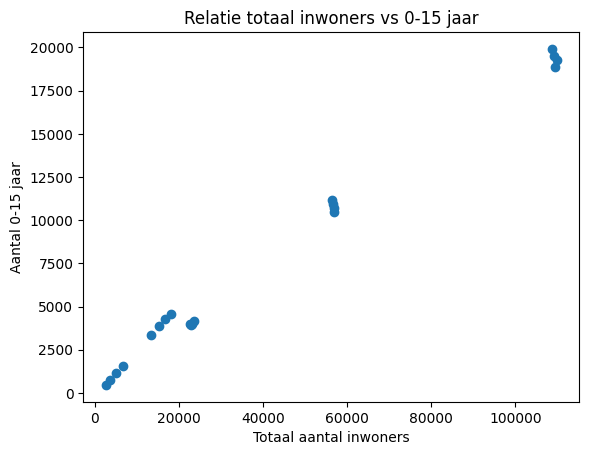

In [213]:
import matplotlib.pyplot as plt

plt.scatter(df["AantalInwoners_5"], df["k_0Tot15Jaar_8"])
plt.xlabel("Totaal aantal inwoners")
plt.ylabel("Aantal 0-15 jaar")
plt.title("Relatie totaal inwoners vs 0-15 jaar")
plt.show()

Deze grafiek toont de relatie tussen het totaal aantal inwoners en het aantal kinderen van 0–15 jaar per wijk.

De punten liggen duidelijk op een stijgende lijn. Dit betekent dat wijken met meer inwoners meestal ook meer kinderen hebben.

Dit is logisch, omdat grotere wijken automatisch meer inwoners in alle leeftijdsgroepen hebben.

In [214]:
df[[
    "AantalInwoners_5",
    "k_0Tot15Jaar_8",
    "k_15Tot25Jaar_9"
]].corr()

,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9
AantalInwoners_5,1.000000,0.996688,0.998529
k_0Tot15Jaar_8,0.996688,1.000000,0.995371
k_15Tot25Jaar_9,0.998529,0.995371,1.000000


De correlatiematrix laat zien dat er een zeer sterke positieve samenhang bestaat tussen:

totaal aantal inwoners

aantal kinderen (0–15)

aantal jongeren (15–25)

De correlatie ligt rond 0.99, wat betekent dat deze variabelen bijna volledig samen bewegen.

Dit komt waarschijnlijk doordat grotere wijken meer inwoners hebben in alle leeftijdsgroepen.

In [215]:
df.groupby("Wijk")[[
    "k_0Tot15Jaar_8",
    "k_15Tot25Jaar_9"
]].mean().sort_values(by="k_0Tot15Jaar_8", ascending=False)

,k_0Tot15Jaar_8,k_15Tot25Jaar_9
Wijk,,
WK003402,19396.25,14845.00
WK003403,10831.25,7840.00
WK003404,4036.25,1418.75
WK003401,4026.25,2446.25
WK003405,987.50,385.00


Hier wordt gekeken of bepaalde wijken structureel meer jongeren hebben dan andere.

Dit helpt om te begrijpen of de jeugdpopulatie gelijkmatig verdeeld is over Almere of dat sommige wijken duidelijk grotere jeugdgroepen hebben.

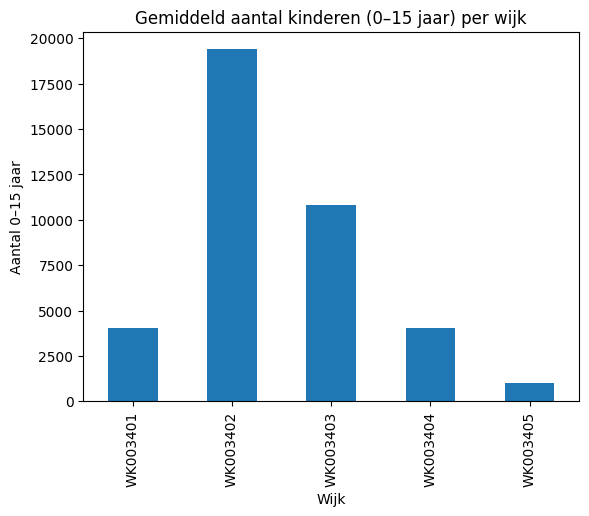

In [216]:
df.groupby("Wijk")["k_0Tot15Jaar_8"].mean().plot(
    kind="bar",
    title="Gemiddeld aantal kinderen (0–15 jaar) per wijk"
)
plt.ylabel("Aantal 0–15 jaar")
plt.xlabel("Wijk")
plt.show()
 

Deze grafiek toont het gemiddelde aantal kinderen van 0–15 jaar per wijk.

Uit de grafiek blijkt dat sommige wijken duidelijk grotere jeugdpopulaties hebben dan andere. Dit betekent dat de verdeling van kinderen over Almere niet gelijkmatig is. Sommige wijken hebben structureel meer kinderen en kunnen daardoor een grotere vraag naar jeugdzorg of onderwijsvoorzieningen hebben.

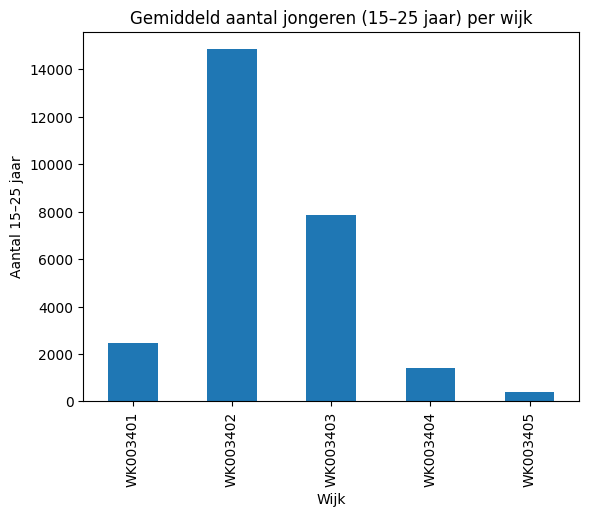

In [217]:
df.groupby("Wijk")["k_15Tot25Jaar_9"].mean().plot(
    kind="bar",
    title="Gemiddeld aantal jongeren (15–25 jaar) per wijk"
)

plt.ylabel("Aantal 15–25 jaar")
plt.xlabel("Wijk")
plt.show()

Deze grafiek toont het gemiddelde aantal jongeren van 15–25 jaar per wijk.

Net als bij de groep 0–15 jaar zijn er duidelijke verschillen tussen wijken. Sommige wijken hebben aanzienlijk meer jongeren dan andere. Dit laat zien dat de leeftijdsstructuur tussen wijken verschilt.

Deze verschillen zijn belangrijk voor het model, omdat voorspellingen per wijk kunnen variëren.

In [218]:
print("Aantal rijen:", len(df))
print("Unieke Wijk-waarden:", df["Wijk"].nunique())
print("Voorbeeld Wijk-waarden:", df["Wijk"].dropna().unique()[:10])

if "Gemeentenaam" in df.columns:
    print("\nGemeentenaam top:", df["Gemeentenaam"].value_counts().head())

if "SoortRegio" in df.columns:
    print("\nSoortRegio verdeling:", df["SoortRegio"].value_counts().head())

Aantal rijen: 20
Unieke Wijk-waarden: 5
Voorbeeld Wijk-waarden: <StringArray>
['WK003401', 'WK003402', 'WK003403', 'WK003404', 'WK003405']
Length: 5, dtype: str


---
# Fase 3 – Data Preparation


**Doel:** In deze fase wordt de dataset voorbereid voor modellering.
De verschillende feature-datasets van het team worden samengevoegd tot één modelklare dataset.

De merge gebeurt op de sleutel:

Wijk

Jaar

De uiteindelijke output van deze fase is:

../../data/processed/df_v12_model_ready.csv

Deze dataset zal in fase 4 gebruikt worden voor het regressiemodel.

In [219]:
import pandas as pd
from pathlib import Path

base_path = Path("../../data/processed/df_v8_ready_for_analysis.csv")
df_base = pd.read_csv(base_path)

df_base.head()

,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar,pct_0_15,pct_15_25
0,2018-01-01,WK003401,22790,3975,2420,2018,17.441860,10.618692
1,2019-01-01,WK003401,22875,3945,2415,2019,17.245902,10.557377
2,2020-01-01,WK003401,23275,4005,2485,2020,17.207304,10.676692
3,2021-01-01,WK003401,23530,4180,2465,2021,17.764556,10.475988
4,2022-01-01,WK003401,1635,175,150,2022,10.703364,9.174312


De basisdataset bevat demografische gegevens per wijk en per jaar.
In de eerste rijen is te zien dat elke observatie bestaat uit een combinatie van Peildatum, Wijk en Jaar.

Voor wijk WK003401 zijn bijvoorbeeld meerdere jaren aanwezig (2018 t/m 2022).
Dit bevestigt dat de dataset een tijdreeks per wijk bevat.

In [220]:
df_base[["Wijk","Jaar"]].head()

df_base.duplicated(subset=["Wijk","Jaar"]).sum()

np.int64(0)

De controle laat zien dat er 0 duplicaten aanwezig zijn voor de combinatie Wijk + Jaar.

Dit betekent dat iedere combinatie van wijk en jaar slechts één keer voorkomt in de dataset.
Hierdoor kan de dataset veilig gebruikt worden voor het samenvoegen met andere datasets.

In [221]:
ratio_path = Path("../../data/processed/df_v10_ratio_temp.csv")

df_ratio = pd.read_csv(ratio_path)

df_ratio.head()

,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar,pct_0_15,pct_15_25,Ratio_0_15,Ratio_15_25
0,2018-01-01,WK003401,22790,3975,2420,2018,17.441860,10.618692,0.174419,0.106187
1,2019-01-01,WK003401,22875,3945,2415,2019,17.245902,10.557377,0.172459,0.105574
2,2020-01-01,WK003401,23275,4005,2485,2020,17.207304,10.676692,0.172073,0.106767
3,2021-01-01,WK003401,23530,4180,2465,2021,17.764556,10.475988,0.177646,0.104760
4,2018-01-01,WK003402,108800,19915,14890,2018,18.304228,13.685662,0.183042,0.136857


De ratio-dataset bevat aanvullende variabelen die de verhouding weergeven tussen de leeftijdsgroepen en de totale bevolking.

Bijvoorbeeld:

Voor wijk WK003401 in 2018:

Ratio_0_15 = 0.174419
Ratio_15_25 = 0.106187

Dit betekent dat:

- ongeveer 17,4% van de bevolking 0–15 jaar is
- ongeveer 10,6% van de bevolking 15–25 jaar is

Deze ratio’s maken het mogelijk om wijken beter met elkaar te vergelijken, omdat ze rekening houden met verschillen in bevolkingsgrootte.

In [222]:
df_ratio = df_ratio[[
    "Wijk",
    "Jaar",
    "Ratio_0_15",
    "Ratio_15_25"
]]

df_ratio.head()

,Wijk,Jaar,Ratio_0_15,Ratio_15_25
0,WK003401,2018,0.174419,0.106187
1,WK003401,2019,0.172459,0.105574
2,WK003401,2020,0.172073,0.106767
3,WK003401,2021,0.177646,0.104760
4,WK003402,2018,0.183042,0.136857


Niet alle kolommen uit de ratio-dataset zijn nodig voor het model.

Daarom worden alleen de variabelen geselecteerd die als feature gebruikt kunnen worden in het regressiemodel.

Dit voorkomt dat onnodige kolommen worden meegenomen in de uiteindelijke dataset.

In [223]:
df_base["Wijk"] = df_base["Wijk"].astype(str).str.strip()
df_ratio["Wijk"] = df_ratio["Wijk"].astype(str).str.strip()

df_base["Jaar"] = df_base["Jaar"].astype(int)
df_ratio["Jaar"] = df_ratio["Jaar"].astype(int)

In [224]:
df_merged = df_base.merge(
    df_ratio,
    on=["Wijk","Jaar"],
    how="left"
)

df_merged.head()

,Peildatum,Wijk,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Jaar,pct_0_15,pct_15_25,Ratio_0_15,Ratio_15_25
0,2018-01-01,WK003401,22790,3975,2420,2018,17.441860,10.618692,0.174419,0.106187
1,2019-01-01,WK003401,22875,3945,2415,2019,17.245902,10.557377,0.172459,0.105574
2,2020-01-01,WK003401,23275,4005,2485,2020,17.207304,10.676692,0.172073,0.106767
3,2021-01-01,WK003401,23530,4180,2465,2021,17.764556,10.475988,0.177646,0.104760
4,2022-01-01,WK003401,1635,175,150,2022,10.703364,9.174312,NaN,NaN


Na het uitvoeren van de merge zijn de kolommen Ratio_0_15 en Ratio_15_25 gevuld met NaN-waarden.

Dit betekent dat er geen overeenkomstige rijen zijn gevonden tussen de basisdataset en de ratio-dataset op basis van de sleutel Wijk + Jaar.

Hoewel het aantal rijen gelijk blijft (237), worden de ratio-waarden niet correct gekoppeld.

Dit wijst erop dat er een verschil bestaat in de sleutelkolommen tussen beide datasets, bijvoorbeeld in datatype of tekstformaat.

In [225]:
print("Rows base:", len(df_base))
print("Rows merged:", len(df_merged))

df_merged.isnull().sum()

Rows base: 237
Rows merged: 237


Peildatum             0
Wijk                  0
AantalInwoners_5      0
k_0Tot15Jaar_8        0
k_15Tot25Jaar_9       0
Jaar                  0
pct_0_15              0
pct_15_25             0
Ratio_0_15          217
Ratio_15_25         217
dtype: int64

Na de merge worden twee controles uitgevoerd:

Aantal rijen controleren

Het aantal rijen moet gelijk blijven.
Als het aantal rijen verandert, betekent dit meestal dat de merge verkeerd is uitgevoerd.

Ontbrekende waarden controleren

Hier wordt gekeken of er NaN-waarden zijn ontstaan bij het toevoegen van de nieuwe features.

In [226]:
df_base.dtypes
df_ratio.dtypes

Wijk               str
Jaar             int64
Ratio_0_15     float64
Ratio_15_25    float64
dtype: object

Alleen variabelen die relevant zijn voor het model worden geselecteerd.

In [227]:
# 1) Filter ratio naar dezelfde jaren als de basis (2018-2021)
df_ratio = df_ratio[df_ratio["Jaar"].isin(df_base["Jaar"].unique())].copy()

print("Jaren base:", sorted(df_base["Jaar"].unique()))
print("Jaren ratio (na filter):", sorted(df_ratio["Jaar"].unique()))

Jaren base: [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]
Jaren ratio (na filter): [np.int64(2018), np.int64(2019), np.int64(2020), np.int64(2021)]


In [228]:
model_cols = [
    "Wijk",
    "Jaar",
    "AantalInwoners_5",
    "k_0Tot15Jaar_8",
    "k_15Tot25Jaar_9",
    "Ratio_0_15",
    "Ratio_15_25"
]

df_model = df_merged[model_cols].copy()

df_model.head()

,Wijk,Jaar,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Ratio_0_15,Ratio_15_25
0,WK003401,2018,22790,3975,2420,0.174419,0.106187
1,WK003401,2019,22875,3945,2415,0.172459,0.105574
2,WK003401,2020,23275,4005,2485,0.172073,0.106767
3,WK003401,2021,23530,4180,2465,0.177646,0.104760
4,WK003401,2022,1635,175,150,NaN,NaN


Niet alle kolommen uit de dataset zijn relevant voor het model.

Daarom wordt een subset van variabelen geselecteerd die gebruikt worden in fase 4.

Deze variabelen bevatten zowel:

- absolute aantallen
- relatieve demografische verhoudingen

In [229]:
# 2) Hoeveel matches hebben we echt?
matches = df_merged[["Ratio_0_15", "Ratio_15_25"]].notna().all(axis=1).sum()
totaal = len(df_merged)

print("Aantal rijen met ratio's gevuld:", matches, "van", totaal)
print("Aantal rijen zonder ratio's:", totaal - matches)

Aantal rijen met ratio's gevuld: 20 van 237
Aantal rijen zonder ratio's: 217


Na de merge controleer ik hoeveel wijk-jaar rijen daadwerkelijk ratio’s hebben gekregen. In mijn output zie ik dat slechts een klein deel gevuld is (bijv. 20 van 237). Dit betekent dat het ratio-bestand niet alle wijken bevat.

In [230]:
df_model.dtypes

Wijk                    str
Jaar                  int64
AantalInwoners_5      int64
k_0Tot15Jaar_8        int64
k_15Tot25Jaar_9       int64
Ratio_0_15          float64
Ratio_15_25         float64
dtype: object

Machine-learning modellen werken alleen met numerieke variabelen.

Daarom controleren we of alle modelvariabelen het juiste datatype hebben.

De kolom Wijk blijft een string omdat deze alleen als identificatie dient.

In [231]:
output_path = Path("../../data/processed/df_v12_model_ready.csv")

df_model.to_csv(output_path, index=False)

output_path

WindowsPath('../../data/processed/df_v12_model_ready.csv')

De uiteindelijke modeldataset wordt opgeslagen in de map data/processed.

Deze dataset vormt de definitieve input voor fase 4 (Modeling), waarin het regressiemodel wordt gebouwd.

In [232]:
df_model.groupby("Wijk")["Jaar"].min(), df_model.groupby("Wijk")["Jaar"].max()

(Wijk
 WK003401    2018
 WK003402    2018
 WK003403    2018
 WK003404    2018
 WK003405    2018
 WK003406    2022
 WK003407    2022
 WK003408    2022
 WK003409    2022
 WK003410    2022
 WK003411    2022
 WK003414    2022
 WK003417    2022
 WK003418    2022
 WK003419    2022
 WK003420    2022
 WK003421    2022
 WK003422    2022
 WK003423    2022
 WK003424    2022
 WK003425    2022
 WK003426    2022
 WK003427    2022
 WK003428    2022
 WK003429    2022
 WK003430    2022
 WK003431    2022
 WK003432    2024
 WK003435    2023
 WK003437    2022
 WK003441    2022
 WK003442    2022
 WK003443    2022
 WK003444    2022
 WK003445    2022
 WK003446    2022
 WK003447    2022
 WK003448    2022
 WK003449    2022
 WK003450    2022
 WK003451    2022
 WK003452    2022
 WK003453    2022
 WK003456    2022
 WK003458    2022
 WK003459    2025
 WK003460    2022
 WK003461    2022
 WK003462    2022
 WK003463    2022
 WK003465    2022
 WK003466    2022
 WK003475    2022
 WK003476    2022
 WK003477    2022
 WK0

In [233]:
df_ratio["Jaar"].unique()


array([2018, 2019, 2020, 2021])

In [234]:
df_base["Jaar"].unique()


array([2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025])

---
# Fase 4 – Modeling 

**Doel:** In deze fase wordt een enkelvoudig lineair regressiemodel gebouwd om te onderzoeken of er een relatie bestaat tussen verschillende demografische variabelen en de omvang van de jeugdpopulatie.

Alle modellen gebruiken dezelfde dataset:

../../data/processed/df_v12_model_ready.csv

De targetvariabele voor alle modellen is:

k_0Tot15Jaar_8

Dit is het aantal jongeren van 0–15 jaar per wijk.

In dit notebook wordt een leeftijdsstructuurmodel getest. Hierbij wordt onderzocht of de grootte van de leeftijdsgroep 15–25 jaar samenhangt met de omvang van de jongere leeftijdsgroep.

Predictor:

k_15Tot25Jaar_9

Target:

k_0Tot15Jaar_8

De centrale vraag is:

Hebben wijken met veel jongeren (15–25 jaar) ook relatief veel kinderen (0–15 jaar)?

In [235]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score

df = pd.read_csv("../../data/processed/df_v12_model_ready.csv")

df.head()

,Wijk,Jaar,AantalInwoners_5,k_0Tot15Jaar_8,k_15Tot25Jaar_9,Ratio_0_15,Ratio_15_25
0,WK003401,2018,22790,3975,2420,0.174419,0.106187
1,WK003401,2019,22875,3945,2415,0.172459,0.105574
2,WK003401,2020,23275,4005,2485,0.172073,0.106767
3,WK003401,2021,23530,4180,2465,0.177646,0.104760
4,WK003401,2022,1635,175,150,NaN,NaN


De modeldataset bevat de variabelen die in fase 3 zijn voorbereid voor modellering.
Elke rij stelt een combinatie van wijk en jaar voor.

In de output is zichtbaar dat de ratio-kolommen (Ratio_0_15, Ratio_15_25) in sommige rijen nog NaN-waarden bevatten. Dit heeft geen invloed op dit model, omdat alleen de variabelen k_15Tot25Jaar_9 en k_0Tot15Jaar_8 worden gebruikt.

In [236]:
X = df[["k_15Tot25Jaar_9"]]
y = df["k_0Tot15Jaar_8"]

print(X.head())
print(y.head())

   k_15Tot25Jaar_9
0             2420
1             2415
2             2485
3             2465
4              150
0    3975
1    3945
2    4005
3    4180
4     175
Name: k_0Tot15Jaar_8, dtype: int64


X bevat de predictorvariabele: het aantal jongeren van 15–25 jaar per wijk.

y bevat de targetvariabele: het aantal jongeren van 0–15 jaar per wijk.

Met dit model testen we of er een lineaire relatie bestaat tussen beide leeftijdsgroepen.

In [237]:
model = LinearRegression()

model.fit(X, y)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


Hier wordt een enkelvoudig lineair regressiemodel getraind.
Het model schat een regressielijn die het verband tussen de predictor (k_15Tot25Jaar_9) en de target (k_0Tot15Jaar_8) zo goed mogelijk beschrijft.

In [238]:
y_pred = model.predict(X)

y_pred[:5]

array([3331.82096322, 3325.22679939, 3417.54509303, 3391.16843771,
        338.07058372])

Met model.predict() berekent het model voorspelde waarden voor het aantal jongeren (0–15 jaar).
Deze voorspellingen zijn gebaseerd op de geschatte regressielijn tussen de twee leeftijdsgroepen.

In [239]:
r2 = r2_score(y, y_pred)

print("R²:", round(r2, 3))

R²: 0.98


De R²-score geeft aan welk deel van de variatie in de targetvariabele door het model wordt verklaard.

In dit model is:

R² = 0.98

Dit betekent dat ongeveer 98% van de variatie in het aantal jongeren van 0–15 jaar kan worden verklaard door het aantal jongeren van 15–25 jaar in dezelfde wijk.

Dit wijst op een zeer sterke lineaire samenhang tussen beide leeftijdsgroepen.

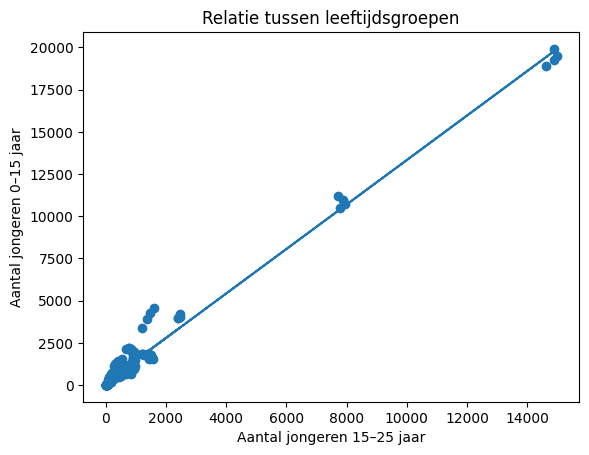

In [240]:
plt.scatter(X, y)

plt.plot(X, y_pred)

plt.xlabel("Aantal jongeren 15–25 jaar")
plt.ylabel("Aantal jongeren 0–15 jaar")

plt.title("Relatie tussen leeftijdsgroepen")

plt.show()

De scatterplot toont de relatie tussen beide leeftijdsgroepen.

Elke stip stelt een wijk-jaar observatie voor.
De lijn is de regressielijn die door het model wordt geschat.

Wanneer de punten dicht bij deze lijn liggen, betekent dit dat het model de relatie goed beschrijft.
Dit komt overeen met de hoge R²-waarde van 0.98.

**Omdat het model wordt geëvalueerd op dezelfde data als waarop het is getraind, geeft de R²-waarde een indicatie van de fit van het model, maar geen onafhankelijke validatie van de voorspellende kracht.**